### Deep learning clasification model

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [20]:
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
min_time, max_time = pd.to_datetime("2013-01-01"), pd.to_datetime("2023-12-31")


fishing_class_ds = xr.open_dataset("../data/processed/targets/cpue_class_HKP_0.1.nc")
fishing_class = fishing_class_ds["CPUE_CLASS"]
fishing_class = fishing_class.fillna(0)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "to_b"})
temp_bottom = temp_bottom_ds["to_b"]
temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo = ugo_ds["ugo"]
ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo = vgo_ds["vgo"]
vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)

maskB_ds = xr.open_dataset("../data/processed/static/fishing_area_mask_buffered_0.1.nc")
maskB = maskB_ds["mask"]
maskB = maskB.broadcast_like(fishing_class)

mask_ds = xr.open_dataset("../data/processed/static/fishing_area_mask_0.1.nc")
mask = mask_ds["mask"]
mask = mask.broadcast_like(fishing_class)

month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month = month.broadcast_like(temp)

year = temp["time"].dt.year
year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = (temp["lat"] - temp["lat"].mean()) / temp["lat"].std()
lon = (temp["lon"] - temp["lon"].mean()) / temp["lon"].std()
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, join="inner")

mask, maskB, fishing_class = xr.align(mask, maskB, fishing_class, join="inner")



croppedT = lambda da: da.sel(
    lon=slice(min_lon, max_lon),
    lat=slice(min_lat, max_lat),
    time=slice(min_time, max_time)
)

cropped = lambda da: da.sel(
    lon=slice(min_lon-1, max_lon+2),  ##modify to obtain diferent results
    lat=slice(min_lat-3, max_lat),
    time=slice(min_time, max_time)
)

fishing_class_target = croppedT(fishing_class)
mask_target = croppedT(mask)
maskB_target = croppedT(maskB)

temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)



In [21]:
y = fishing_class_target  # (time, lat, lon)
y = y.transpose("time", "lat", "lon")

m = mask_target
m = m.transpose("time", "lat", "lon")


vars_ = [temp, so, 
        ugo, vgo, chl, cdm,
        pp, temp_bottom, mixed, zo, 
        # month_sin, month_cos,
        # lat, lon,
        # depth,
        ]
vars_names = [v.name for v in vars_]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")


split_year = 2020

train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year}-01-01", None))

train_m = m.sel(time=slice(None, f"{split_year-1}-12-31"))
test_m  = m.sel(time=slice(f"{split_year}-01-01", None))


# -------- Check inflation factor --------
X_np = train_X.values  # (time, channel, lat, lon)
t, c, h, w = X_np.shape
X_flat = X_np.reshape(t, c, -1)       # (time, channel, pixels)
X_flat = X_flat.transpose(0, 2, 1)    # (time, pixels, channel)
X_flat = X_flat.reshape(-1, c)        # (samples, channel)
df = pd.DataFrame(X_flat, columns=vars_names)
vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)for i in range(df.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

def create_windows(X, y, m, window=10):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)
    m_data = m.values   # (time, H, W)  #this won't be used

    X_seq, y_seq, m_seq= [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window])
        y_seq.append(y_data[i+window])
        m_seq.append(m_data[i+window])
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
    )

window = 12

X_train, y_train, m_train = create_windows(train_X, train_y, train_m, window)
X_test, y_test, m_test= create_windows(test_X, test_y, test_m, window)

print(X_train.shape)  # (N, T, C, H, W)
print(y_train.shape)  # (N, H, W)
print(m_train.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test),
    batch_size=batch_size,
    shuffle=False
)

  feature        VIF
9      zo  11.531013
7    to_b  10.132864
4     CHL   7.647407
6      PP   7.428247
1      so   7.047682
3     ugo   3.197752
2     vgo   2.930630
5     CDM   2.322628
8  mlotst   2.242045
0      to   2.236450
torch.Size([72, 12, 10, 46, 32])
torch.Size([72, 27, 10])
torch.Size([72, 27, 10])


In [22]:
# -------- UNet 3D model--------

# -------- Basic Conv Block --------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.GELU(),
            nn.Dropout3d(0.2),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.GELU()
            )

    def forward(self, x):
        return self.block(x)


# -------- Decoder Block --------
class DecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, (1, 2, 2), stride=(1, 2, 2))
        self.conv_block = ConvBlock(out_channels + skip_channels, out_channels)
        
    def forward(self, x, skip):
        x = self.up(x)

        # Handle size mismatches
        x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)

        x = self.conv_block(x)
        return x

# -------- Temporal Attention Block --------
class TemporalAttentionBlock3D(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.temporal_attn = nn.Sequential(
            nn.Conv3d(in_channels, in_channels, kernel_size=(3, 1, 1), padding=(1, 0, 0), groups=in_channels),
            nn.Sigmoid()
        )
        self.temporal_score = nn.Conv3d(in_channels, 1, kernel_size=1)
    
    def forward(self, x):
        # x shape: (B, C, T, H, W)
        attn = self.temporal_attn(x)
        feat = x * attn
        score = self.temporal_score(feat)
        weights = torch.softmax(score, dim=2) 
        feat = (feat * weights).sum(dim=2)    
        return feat

class GlobalAttentionBranch(nn.Module):
    def __init__(self, channels):
        super().__init__()
        reduction = max(channels // 4, 8)
        self.branch = nn.Sequential(
            nn.AdaptiveAvgPool3d((None, 1, 1)),
            nn.Conv3d(channels, reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv3d(reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.branch(x)

# -------- U-Net 3D --------
class UNet3D(nn.Module):
    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=10):
        super().__init__()

        self.out_hw = out_hw  # (H, W)

        # -------- Encoder --------
        self.enc1 = ConvBlock(in_channels, base_ch)
        self.pool1 = nn.MaxPool3d((1,2,2))

        self.enc2 = ConvBlock(base_ch, base_ch*2)
        self.pool2 = nn.MaxPool3d((1,2,2)) #(1, 2, 2) for no temporal downsampling (2, 2, 2) for temporal downsampling


        # -------- Bottleneck --------
        self.bottleneck = ConvBlock(base_ch*2, base_ch*4)
        self.temp_mix = nn.Sequential(nn.Conv3d(base_ch*4, base_ch*4, kernel_size=(3,1,1), padding=(1,0,0)))
        self.global_att_branch = GlobalAttentionBranch(base_ch * 4)
        # -------- Temporal Attention --------
        self.temporal_attention = TemporalAttentionBlock3D(base_ch*4)

        # -------- Decoder --------
        self.decoder2 = DecoderBlock3D(base_ch*4, base_ch*2, base_ch*2)
        self.decoder1 = DecoderBlock3D(base_ch*2, base_ch, base_ch)
    

        # -------- Classifier Head --------
        self.classifier = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Conv2d(base_ch, 3, 1)  
        )
        

    def forward(self, x):
        # INPUT COMES AS: (B, T, C, H, W) Convert to:(B, C, T, H, W)
        
        x = x.permute(0, 2, 1, 3, 4)
        # -------- Encoder --------
        s1 = self.enc1(x)
        p1 = self.pool1(s1)

        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # -------- Bottleneck --------
        b = self.bottleneck(p2)
        b = b + self.temp_mix(b)
        att = self.global_att_branch(b)
        b = b * att

        # temporal aggregation BEFORE decoder
        b = self.temporal_attention(b)  # (B,C,H,W)

        # fake temporal dim for decoder compatibility
        b = b.unsqueeze(2)
        s2 = s2.mean(dim=2, keepdim=True)
        s1 = s1.mean(dim=2, keepdim=True)

        # -------- Decoder --------
        d2 = self.decoder2(b, s2)
        d1 = self.decoder1(d2, s1)

        # final projection to output
        d1 = d1.squeeze(2)
        logits = self.classifier(d1)

        # IMPORTANT: use nearest for segmentation stability
        logits = F.interpolate(
            logits,
            size=self.out_hw,
            mode="nearest"
        )

        return logits


In [23]:
def loss_fn(logits, targets, weights):
    return F.cross_entropy(
        logits,
        targets.long(),
        weight=weights
    )

Epoch 1/500 | Loss: 1.0947 | F1_1: 0.251 | F1_2: 0.000 | Acc: 0.144 | P1: 0.144 R1: 1.000 | P2: 0.000 R2: 0.000
Epoch 2/500 | Loss: 1.0572 | F1_1: 0.251 | F1_2: 0.000 | Acc: 0.144 | P1: 0.144 R1: 1.000 | P2: 0.000 R2: 0.000
Epoch 3/500 | Loss: 1.0313 | F1_1: 0.251 | F1_2: 0.000 | Acc: 0.144 | P1: 0.144 R1: 1.000 | P2: 0.000 R2: 0.000
Epoch 4/500 | Loss: 1.0077 | F1_1: 0.251 | F1_2: 0.000 | Acc: 0.144 | P1: 0.144 R1: 1.000 | P2: 0.000 R2: 0.000
Epoch 5/500 | Loss: 0.9881 | F1_1: 0.251 | F1_2: 0.000 | Acc: 0.144 | P1: 0.144 R1: 1.000 | P2: 0.000 R2: 0.000
Epoch 6/500 | Loss: 0.9736 | F1_1: 0.251 | F1_2: 0.000 | Acc: 0.144 | P1: 0.144 R1: 1.000 | P2: 0.000 R2: 0.000
Epoch 7/500 | Loss: 0.9618 | F1_1: 0.251 | F1_2: 0.000 | Acc: 0.144 | P1: 0.144 R1: 1.000 | P2: 0.000 R2: 0.000
Epoch 8/500 | Loss: 0.9506 | F1_1: 0.281 | F1_2: 0.000 | Acc: 0.273 | P1: 0.164 R1: 0.985 | P2: 0.000 R2: 0.000
Epoch 9/500 | Loss: 0.9346 | F1_1: 0.334 | F1_2: 0.000 | Acc: 0.501 | P1: 0.208 R1: 0.840 | P2: 0.000 R2

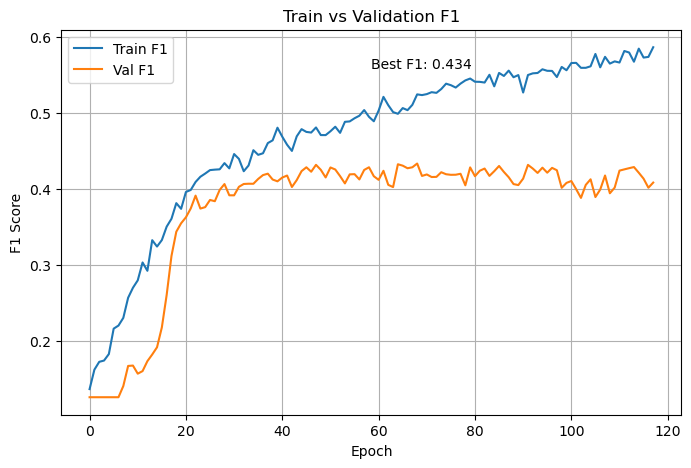

In [ ]:
def compute_metrics_multiclass(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),

        # Class 1
        "precision_1": precision_score(y_true, y_pred, labels=[1], average="macro", zero_division=0),
        "recall_1": recall_score(y_true, y_pred, labels=[1], average="macro", zero_division=0),
        "f1_1": f1_score(y_true, y_pred, labels=[1], average="macro", zero_division=0),

        # Class 2
        "precision_2": precision_score(y_true, y_pred, labels=[2], average="macro", zero_division=0),
        "recall_2": recall_score(y_true, y_pred, labels=[2], average="macro", zero_division=0),
        "f1_2": f1_score(y_true, y_pred, labels=[2], average="macro", zero_division=0),
    }


out_hw = y_train.shape[1:]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet3D(in_channels=in_channels, out_hw=out_hw).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
weights = torch.tensor([1.0, 3.0, 2.0]).to(device)

best_val_f1 = -float("inf")
patience = 50
counter = 0
epochs = 500

train_f1_history = []
val_f1_history = []


for epoch in range(epochs):

    # ---------------- TRAIN ----------------
    model.train()

    train_preds = []
    train_trues = []

    total_loss = 0

    for x, y, _ in train_loader:

        x = x.to(device)
        y = y.to(device)  # (B,H,W)

        optimizer.zero_grad()

        logits = model(x)  # (B,3,H,W)

        loss = loss_fn(logits, y, weights)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.softmax(logits, dim=1).argmax(dim=1)

        train_preds.append(preds.detach().cpu().numpy().reshape(-1))
        train_trues.append(y.detach().cpu().numpy().reshape(-1))

    y_true = np.concatenate(train_trues)
    y_pred = np.concatenate(train_preds)

    train_metrics = compute_metrics_multiclass(y_true, y_pred)

    # ---------------- VALIDATION ----------------
    model.eval()

    val_preds = []
    val_trues = []

    with torch.no_grad():
        for x, y, _ in test_loader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            preds = torch.softmax(logits, dim=1).argmax(dim=1)

            val_preds.append(preds.cpu().numpy().reshape(-1))
            val_trues.append(y.cpu().numpy().reshape(-1))

    y_true_val = np.concatenate(val_trues)
    y_pred_val = np.concatenate(val_preds)

    val_metrics = compute_metrics_multiclass(y_true_val, y_pred_val)

    val_f1 = (val_metrics["f1_1"] + val_metrics["f1_2"]) / 2 

    # ---------------- EARLY STOPPING ----------------
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {total_loss/len(train_loader):.4f} | "
        f"F1_1: {val_metrics['f1_1']:.3f} | "
        f"F1_2: {val_metrics['f1_2']:.3f} | "
        f"P1: {val_metrics['precision_1']:.3f} R1: {val_metrics['recall_1']:.3f} | "
        f"P2: {val_metrics['precision_2']:.3f} R2: {val_metrics['recall_2']:.3f}"
    )

    train_f1_history.append((train_metrics["f1_1"] + train_metrics["f1_2"]) / 2)
    val_f1_history.append(val_f1)
    best_val_f1 = max(val_f1_history)



plt.figure(figsize=(8,5))

plt.plot(train_f1_history, label="Train F1")
plt.plot(val_f1_history, label="Val F1")

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Train vs Validation F1")
plt.annotate(f"Best Val F1: {best_val_f1:.3f}", xy=(0.5, 0.9), xycoords="axes fraction")
plt.legend()
plt.grid(True)

plt.show()